In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/Swahili_Audio_Project'
for sub in ['results', 'models', 'submissions']:
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)
print("Base dir ready:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base dir ready: /content/drive/MyDrive/Swahili_Audio_Project


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.utils import to_categorical

In [10]:
ZIP_PATH = '/content/w1.5_energy_mfcc40_d.zip'
print("Exists:", os.path.exists(ZIP_PATH))
print("Size (MB):", round(os.path.getsize(ZIP_PATH) / 1e6, 2))

Exists: True
Size (MB): 277.49


In [11]:
import zipfile, time, os

EXTRACT_DIR = '/content/dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

t0 = time.time()
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print(f"Extracted in {time.time()-t0:.1f}s")

Extracted in 4.1s


In [40]:
DATA_DIR = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'train.npz' in files:
        DATA_DIR = root
        break

assert DATA_DIR is not None, "train.npz not found"
print("DATA_DIR =", DATA_DIR)
for f in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, f)
    if os.path.isfile(p):
        print(f"  {f}  ({os.path.getsize(p)/1e6:.2f} MB)")

DATA_DIR = /content/dataset/w1.5_energy_mfcc40_d
  labels.json  (0.00 MB)
  test.npz  (41.63 MB)
  train.npz  (194.21 MB)
  val.npz  (41.60 MB)


In [41]:
import json, numpy as np

with open(os.path.join(DATA_DIR, 'labels.json')) as f:
    LABELS = json.load(f)
print("labels.json:", LABELS)

for name in ['train', 'val', 'test']:
    d = np.load(os.path.join(DATA_DIR, f'{name}.npz'), allow_pickle=True)
    print(f"\n=== {name}.npz ===")
    for k in d.files:
        print(f"  {k}: shape={d[k].shape}, dtype={d[k].dtype}")

labels.json: {'hapana': 0, 'kumi': 1, 'mbili': 2, 'moja': 3, 'nane': 4, 'ndio': 5, 'nne': 6, 'saba': 7, 'sita': 8, 'tano': 9, 'tatu': 10, 'tisa': 11}

=== train.npz ===
  X: shape=(2940, 151, 120), dtype=float32
  y: shape=(2940,), dtype=int64
  ids: shape=(2940,), dtype=object

=== val.npz ===
  X: shape=(630, 151, 120), dtype=float32
  y: shape=(630,), dtype=int64
  ids: shape=(630,), dtype=object

=== test.npz ===
  X: shape=(630, 151, 120), dtype=float32
  y: shape=(630,), dtype=int64
  ids: shape=(630,), dtype=object


In [42]:
train_npz = np.load(os.path.join(DATA_DIR, 'train.npz'), allow_pickle=True)
val_npz   = np.load(os.path.join(DATA_DIR, 'val.npz'),   allow_pickle=True)
test_npz  = np.load(os.path.join(DATA_DIR, 'test.npz'),  allow_pickle=True)

def pick(npz, candidates, label='array'):
    for c in candidates:
        if c in npz.files:
            return c
    raise KeyError(f"No {label} key. Tried {candidates}. Available: {npz.files}")

XK = ['X', 'mfcc', 'features', 'X_mfcc', 'mel', 'spectrograms']
yK = ['y', 'labels', 'targets']

X_train = train_npz[pick(train_npz, XK, 'X')]
y_train = train_npz[pick(train_npz, yK, 'y')]
X_val   = val_npz[pick(val_npz, XK, 'X')]
y_val   = val_npz[pick(val_npz, yK, 'y')]
X_test  = test_npz[pick(test_npz, XK, 'X')]

idx_to_label = {v: k for k, v in LABELS.items()}
CLASS_NAMES  = [idx_to_label[i] for i in range(len(LABELS))]
NUM_CLASSES  = len(CLASS_NAMES)

# Safety: if y came as one-hot, flatten
if y_train.ndim > 1 and y_train.shape[1] == NUM_CLASSES:
    y_train = np.argmax(y_train, axis=1)
    y_val   = np.argmax(y_val,   axis=1)

print("Class order:", CLASS_NAMES)
print("Shapes:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("  X_test :", X_test.shape)

Class order: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']
Shapes:
  X_train: (2940, 151, 120) y_train: (2940,)
  X_val  : (630, 151, 120) y_val  : (630,)
  X_test : (630, 151, 120)


In [44]:
def to_seq_format(X, feat_candidates=(40, 41, 120)): # Added 120 to feat_candidates
    F = X.shape[-1]
    if F in feat_candidates:
        print(f"Already (N, T, F) with F={F}: {X.shape}")
        return X
    # look for the feature axis elsewhere
    for axis in [1, 2]:
        if X.shape[axis] in feat_candidates:
            X = np.transpose(X, (0, 2, 1)) if axis == 1 else X
            print(f"Reordered axis {axis} -> (N, T, F): {X.shape}")
            return X
    raise ValueError(f"Cannot locate feature axis in {X.shape}")

X_train = to_seq_format(X_train)
X_val   = to_seq_format(X_val)
X_test  = to_seq_format(X_test)

TIMESTEPS  = X_train.shape[1]
N_FEATURES = X_train.shape[2]
print(f"\nTIMESTEPS = {TIMESTEPS}, N_FEATURES = {N_FEATURES}")

Already (N, T, F) with F=120: (2940, 151, 120)
Already (N, T, F) with F=120: (630, 151, 120)
Already (N, T, F) with F=120: (630, 151, 120)

TIMESTEPS = 151, N_FEATURES = 120


In [45]:
mean = X_train.mean()
std  = X_train.std()

X_train = ((X_train - mean) / (std + 1e-8)).astype(np.float32)
X_val   = ((X_val   - mean) / (std + 1e-8)).astype(np.float32)
X_test  = ((X_test  - mean) / (std + 1e-8)).astype(np.float32)
print("Post-norm train mean/std:", X_train.mean().round(4), X_train.std().round(4))

Post-norm train mean/std: 0.0 1.0


In [46]:
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)
print("y_train_oh:", y_train_oh.shape, "| y_val_oh:", y_val_oh.shape)

y_train_oh: (2940, 12) | y_val_oh: (630, 12)


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

def build_gru(T, F, C, gru1=128, gru2=64, dropout=0.4, lr=1e-3):
    inp = layers.Input(shape=(T, F), name='input')
    x = layers.GRU(gru1, return_sequences=True)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.GRU(gru2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    out = layers.Dense(C, activation='softmax')(x)

    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

model = build_gru(TIMESTEPS, N_FEATURES, NUM_CLASSES)
model.summary()

SpecAugment OK — in: (2, 151, 120) out: (2, 151, 120)


In [47]:
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers

def build_bigru(T, F, C,
                gru1=96, gru2=48,
                dropout=0.5, l2=1e-4, input_noise=0.01, lr=1e-3):
    reg = regularizers.l2(l2)

    inp = layers.Input(shape=(T, F), name='input')

    # Augmentation
    x = layers.GaussianNoise(input_noise)(inp)
    x = SpecAugment(freq_mask=8, time_mask=10, n_masks=2, name='specaug')(x)

    # BiGRU stack
    x = layers.Bidirectional(
        layers.GRU(gru1, return_sequences=True, kernel_regularizer=reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(
        layers.GRU(gru2, kernel_regularizer=reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Classifier head
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout * 0.6)(x)
    out = layers.Dense(C, activation='softmax')(x)

    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

model = build_bigru(TIMESTEPS, N_FEATURES, NUM_CLASSES)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_2                │ (None, 151, 120)       │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ specaug (SpecAugment)           │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 151, 192)       │       125,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 151, 192)       │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 151, 192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 96)             │        69,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,404 (794.55 KB)

 Trainable params: 202,828 (792.30 KB)

 Non-trainable params: 576 (2.25 KB)

In [48]:
CKPT = f'{BASE}/models/best_gru_mfcc.keras'

cbs = [
    callbacks.ModelCheckpoint(CKPT, monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=4, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=60,
    batch_size=64,
    callbacks=cbs,
    verbose=1,
)

Epoch 1/60
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0767 - loss: 3.5108
Epoch 1: val_accuracy improved from None to 0.10159, saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.0837 - loss: 3.3416 - val_accuracy: 0.1016 - val_loss: 2.5795 - learning_rate: 0.0010
Epoch 2/60
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1019 - loss: 3.0230
Epoch 2: val_accuracy improved from 0.10159 to 0.11587, saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_gru_mfcc.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1085 - loss: 2.9578 - val_accuracy: 0.1159 - val_loss: 2.5240 - learning_rate: 0.0010
Epoch 3/60
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step 

Val Accuracy: 0.9381
Val Macro-F1: 0.9382

              precision    recall  f1-score   support

      hapana       0.96      0.96      0.96        53
        kumi       0.96      0.94      0.95        52
       mbili       0.98      0.91      0.94        53
        moja       0.96      0.96      0.96        52
        nane       0.92      0.87      0.89        52
        ndio       0.93      0.94      0.93        53
         nne       0.91      0.92      0.91        52
        saba       0.96      1.00      0.98        52
        sita       0.98      0.94      0.96        53
        tano       0.98      0.91      0.94        53
        tatu       0.86      0.94      0.90        53
        tisa       0.88      0.96      0.92        52

    accuracy                           0.94       630
   macro avg       0.94      0.94      0.94       630
weighted avg       0.94      0.94      0.94       630



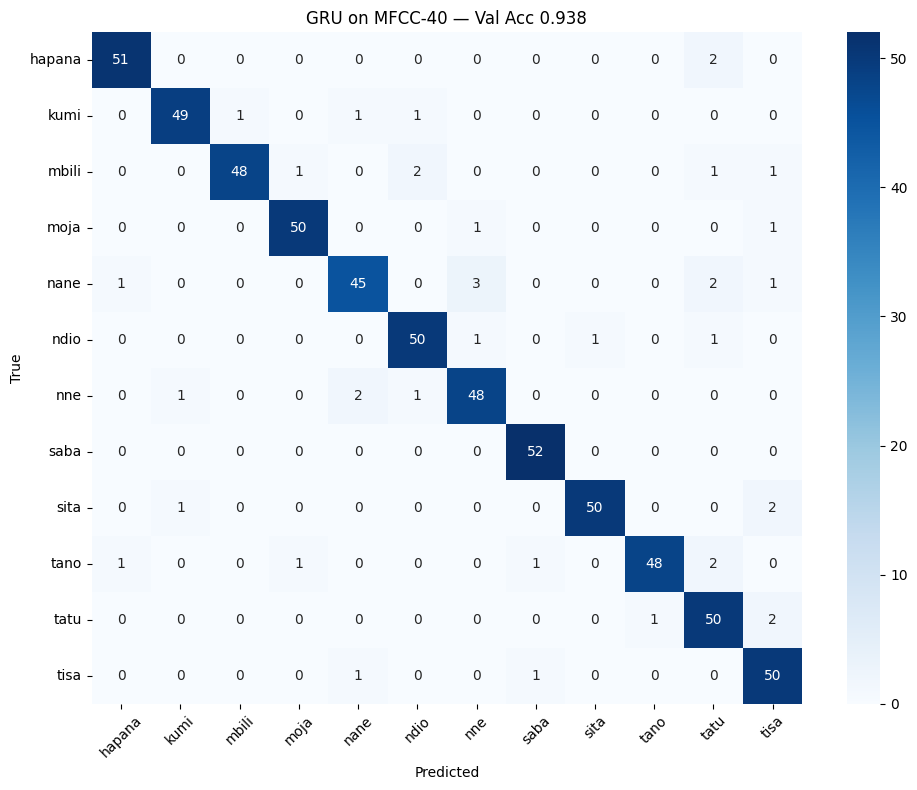

In [49]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_val, y_pred)
f1  = f1_score(y_val, y_pred, average='macro')

print(f"Val Accuracy: {acc:.4f}")
print(f"Val Macro-F1: {f1:.4f}\n")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'GRU on MFCC-40 — Val Acc {acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_confusion.png', dpi=150)
plt.show()

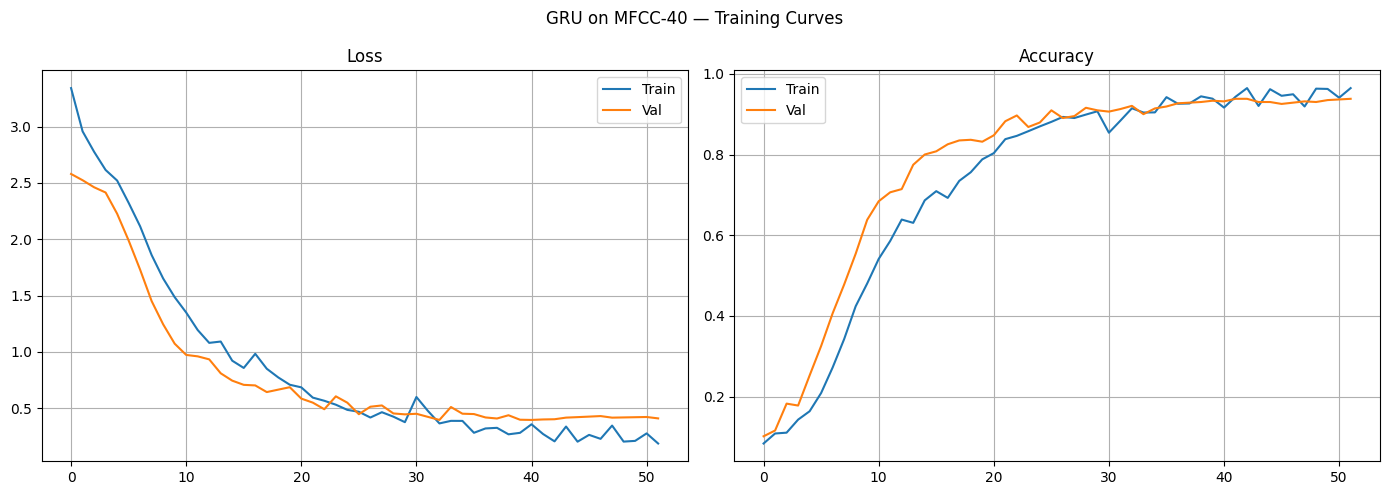

Results CSV saved.


In [51]:
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('GRU on MFCC-40 — Training Curves')
plt.tight_layout()
plt.savefig(f'{BASE}/results/gru_mfcc_learning_curves.png', dpi=150)
plt.show()

pd.DataFrame([{
    'model': 'GRU (MFCC-40)',
    'val_accuracy': acc,
    'val_macro_f1': f1,
    'epochs_trained': len(history.history['loss']),
    'params': model.count_params(),
}]).to_csv(f'{BASE}/results/gru_mfcc_results.csv', index=False)
print("Results CSV saved.")

In [52]:
test_probs = model.predict(X_test, verbose=0)
print("Test probs shape:", test_probs.shape)

# Column order
sample_sub_path = os.path.join(DATA_DIR, 'SampleSubmission.csv')
if os.path.exists(sample_sub_path):
    class_cols = list(pd.read_csv(sample_sub_path, nrows=0).columns[1:])
else:
    class_cols = CLASS_NAMES
print("Submission columns:", class_cols)

col_idx = [CLASS_NAMES.index(c) for c in class_cols]
probs_ordered = test_probs[:, col_idx]

# IDs
id_keys = ['Word_id', 'word_ids', 'ids', 'id']
test_ids = None
if any(k in test_npz.files for k in id_keys):
    test_ids = test_npz[pick(test_npz, id_keys, 'IDs')]
    print("IDs from test.npz")
elif os.path.exists(os.path.join(DATA_DIR, 'Test.csv')):
    test_ids = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))['Word_id'].values
    print("IDs from Test.csv")

# If still missing, warn but don't fail (still saves a positional submission)
if test_ids is None:
    print("WARNING: no test IDs found — using positional index")
    test_ids = [f'test_{i}.wav' for i in range(len(probs_ordered))]

sub = pd.DataFrame({'Word_id': test_ids})
for j, c in enumerate(class_cols):
    sub[c] = probs_ordered[:, j]

print(sub.head())
print("Row sums:", sub[class_cols].sum(axis=1).describe().round(4))

sub.to_csv(f'{BASE}/submissions/gru_mfcc_submission.csv', index=False)
print("Saved:", f'{BASE}/submissions/gru_mfcc_submission.csv')

Test probs shape: (630, 12)
Submission columns: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']
IDs from test.npz
               Word_id        hapana          kumi         mbili  \
0  id_v8rz06e6rv31.wav  1.030772e-07  7.881906e-06  9.999309e-01   
1  id_twhce0u5wcg0.wav  9.992881e-01  3.874784e-05  3.684989e-07   
2  id_3komqnffiaet.wav  1.879109e-05  8.212740e-07  4.507879e-08   
3  id_lbhxpmz7zdxl.wav  1.028452e-06  1.171140e-07  9.836996e-07   
4  id_giv6yxiwwxsw.wav  1.489535e-03  9.583640e-05  2.139332e-04   

           moja          nane          ndio           nne          saba  \
0  7.654107e-10  2.787527e-07  3.462219e-05  2.519320e-05  9.079928e-10   
1  3.124075e-04  9.356094e-06  1.500937e-07  2.518159e-07  1.596718e-05   
2  9.999048e-01  2.173254e-05  7.209722e-06  4.440186e-05  1.766692e-06   
3  5.058775e-06  9.999286e-01  1.634125e-07  3.734878e-05  2.459491e-08   
4  4.025280e-03  9.903960e-01  9.951201e-05  2.3429